<a href="https://colab.research.google.com/github/Bibhusha123/Mortgage_Loan_AI_Model.ipynb/blob/AI-Model/Mortgage_Loan_AI_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving DGS10.csv to DGS10.csv


In [3]:
import pandas as pd

# Load the dataset (replace filename if needed)
df = pd.read_csv('DGS10.csv')

# Show first 5 rows
df.head()

,DATE,DGS10
0,1962-01-02,4.06
1,1962-01-03,4.03
2,1962-01-04,3.99
3,1962-01-05,4.02
4,1962-01-08,4.03


In [4]:
# Check number of rows and columns
print("Shape of dataset:", df.shape)

# Check data types and missing values
df.info()

# Check basic statistics
df.describe()


Shape of dataset: (14883, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14883 entries, 0 to 14882
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   DATE    14883 non-null  object
 1   DGS10   14883 non-null  object
dtypes: object(2)
memory usage: 232.7+ KB


,DATE,DGS10
count,14883,14883
unique,14883,1319
top,2019-01-17,.
freq,1,637


In [5]:
df.columns

Index(['DATE', 'DGS10'], dtype='object')

In [6]:
# Convert DATE column to datetime format
df['DATE'] = pd.to_datetime(df['DATE'])

# Set DATE as the index
df.set_index('DATE', inplace=True)

# Drop rows with missing values
df = df.dropna()

# Confirm the changes
df.head()


,DGS10
DATE,
1962-01-02,4.06
1962-01-03,4.03
1962-01-04,3.99
1962-01-05,4.02
1962-01-08,4.03


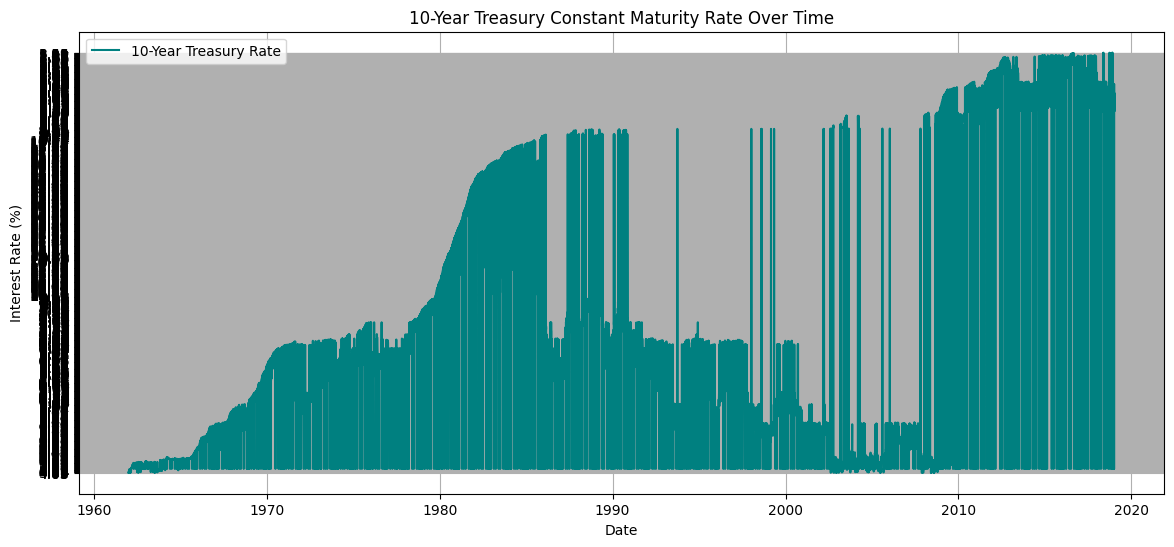

In [7]:
import matplotlib.pyplot as plt

# Plot the 10-Year Treasury Rate over time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['DGS10'], label='10-Year Treasury Rate', color='teal')
plt.title('10-Year Treasury Constant Maturity Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Interest Rate (%)')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Convert dates to ordinal for regression
df['date_ordinal'] = df.index.map(lambda date: date.toordinal())

# Drop NA just in case
df = df.dropna()

# Features and target
X = df['date_ordinal'].values.reshape(-1, 1)
y = df['DGS10'].values.reshape(-1, 1)

# Train/test split
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Plot actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(df.index[split_idx:], y_test, label='Actual Rate', color='blue')
plt.plot(df.index[split_idx:], y_pred, label='Predicted Rate', color='orange')
plt.title('Actual vs Predicted 10-Year Treasury Rate')
plt.xlabel('Date')
plt.ylabel('Interest Rate (%)')
plt.legend()
plt.grid(True)
plt.show()


ValueError: could not convert string to float: '.'

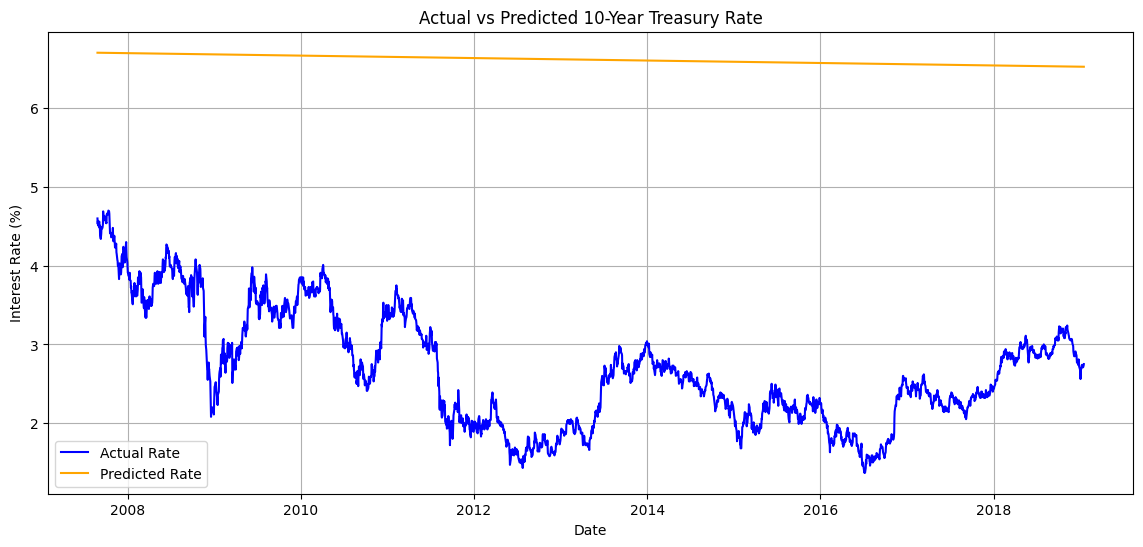

In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd # Import pandas

# Convert dates to ordinal for regression
df['date_ordinal'] = df.index.map(lambda date: date.toordinal())

# Convert 'DGS10' to numeric, coercing errors to NaN
df['DGS10'] = pd.to_numeric(df['DGS10'], errors='coerce')

# Drop rows with any remaining missing values (including those created by the coercion)
df = df.dropna()

# Features and target
X = df['date_ordinal'].values.reshape(-1, 1)
y = df['DGS10'].values.reshape(-1, 1)

# Train/test split
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Plot actual vs predicted
import matplotlib.pyplot as plt # Import matplotlib
plt.figure(figsize=(14, 6))
plt.plot(df.index[split_idx:], y_test, label='Actual Rate', color='blue')
plt.plot(df.index[split_idx:], y_pred, label='Predicted Rate', color='orange')
plt.title('Actual vs Predicted 10-Year Treasury Rate')
plt.xlabel('Date')
plt.ylabel('Interest Rate (%)')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Install TensorFlow (usually already available in Colab)
!pip install -q tensorflow

In [15]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [16]:
# Load your dataset again
df = pd.read_csv("DGS10.csv")

# Clean and prepare the data
df = df.dropna()
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)
data = df[['DGS10']].values  # Use just the interest rate column

# Scale the data between 0 and 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Show a few rows
print(df.head())

ValueError: could not convert string to float: '.'

In [17]:
# Load your dataset again
df = pd.read_csv("DGS10.csv")

# Clean and prepare the data
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)

# Convert 'DGS10' to numeric, coercing errors to NaN
# This is crucial to handle non-numeric entries like '.'
df['DGS10'] = pd.to_numeric(df['DGS10'], errors='coerce')

# Drop rows with any remaining missing values (including those created by the coercion)
df = df.dropna()

# Use just the interest rate column for scaling
data = df[['DGS10']].values

# Scale the data between 0 and 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Show a few rows and confirm data type
print(df.head())
print("\nData type of 'DGS10' after cleaning:", df['DGS10'].dtype)

            DGS10
DATE             
1962-01-02   4.06
1962-01-03   4.03
1962-01-04   3.99
1962-01-05   4.02
1962-01-08   4.03

Data type of 'DGS10' after cleaning: float64


In [18]:
# Create sequences of 60 time steps
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i - sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape X to fit LSTM input (samples, time steps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (14186, 60, 1)
y shape: (14186,)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Predicting one value

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X, y, epochs=20, batch_size=32)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 32s 61ms/step - loss: 0.0093
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - loss: 0.0011
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - loss: 9.0668e-04
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - loss: 6.8473e-04
Epoch 5/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - loss: 6.0907e-04
Epoch 6/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 39s 60ms/step - loss: 5.1759e-04
Epoch 7/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 43s 64ms/step - loss: 4.3639e-04
Epoch 8/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step - loss: 3.9251e-04
Epoch 9/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - loss: 3.7848e-04
Epoch 10/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - loss: 3.9355e-04
Epoch 11/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - loss: 3.6633e-04
Epoch 12/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - loss: 3.3210e-04
Epoch 13/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 43s 63ms/step - loss: 3.7636e-04
Epoch 14/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step 